# 02 — Construction d'un Modele de Sentiment avec PySpark MLlib

**Objectif** : Construire un pipeline de Machine Learning capable de predire le sentiment (positif/negatif) d'un tweet a partir de son texte.

**Ce modele sera reutilise en Phase 2** pour l'inference en temps reel dans le pipeline Kafka-Spark.

**Architecture du pipeline ML** :
Texte brut → Nettoyage → Tokenization → Stop Words → TF-IDF → Logistic Regression

In [1]:
import os
username = os.environ.get('USER', 'unknown')

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName(f"ML-Sentiment-{username}") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.instances", "2") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"SparkSession creee : {spark.version} (master: {spark.conf.get('spark.master')})")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/08 22:07:44 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/02/08 22:07:46 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


SparkSession creee : 3.5.3 (master: yarn)


## 1. Chargement et exploration des donnees

In [2]:
from pyspark.sql.functions import col, when

# ============================================================
# TODO [Exercice 1.1] : Chargement des donnees depuis HDFS
#
# Consigne : Chargez le dataset tweets_dev.csv depuis HDFS,
#            renommez les colonnes et convertissez le sentiment en entier.
#
# Indice   : spark.read.csv("hdfs:///data/tweets/tweets_dev.csv", header=False)
#            .toDF("sentiment", "tweet_id", "date", "query", "user", "text")
#            .withColumn("sentiment", col("sentiment").cast("int"))
#            Le resultat doit s'appeler 'df'
#
# Attendu  : Un DataFrame 'df' avec ~1M lignes et 6 colonnes typees
# ============================================================

df = spark.read.csv("hdfs:///data/tweets/tweets_dev.csv", header=False)
df = df.withColumnRenamed("_c0", "sentiment").withColumnRenamed("_c5", "text").withColumnRenamed("_c1", "tweet_id").withColumnRenamed("_c2", "date").withColumnRenamed("_c3", "query").withColumnRenamed("_c4", "user")

df = df.withColumn("sentiment", col("sentiment").cast("int"))
df = df.withColumn("label", when(col("sentiment") == 4, 1.0).otherwise(0.0))

print("Nombre total de tweets : ", df.count())
df.printSchema()
df.show(5)

Nombre total de tweets :  1000000
root
 |-- sentiment: integer (nullable = true)
 |-- tweet_id: string (nullable = true)
 |-- date: string (nullable = true)
 |-- query: string (nullable = true)
 |-- user: string (nullable = true)
 |-- text: string (nullable = true)
 |-- label: double (nullable = false)

+---------+----------+--------------------+--------+---------------+--------------------+-----+
|sentiment|  tweet_id|                date|   query|           user|                text|label|
+---------+----------+--------------------+--------+---------------+--------------------+-----+
|        0|1467810369|Mon Apr 06 22:19:...|NO_QUERY|_TheSpecialOne_|@switchfoot http:...|  0.0|
|        0|1467810672|Mon Apr 06 22:19:...|NO_QUERY|  scotthamilton|is upset that he ...|  0.0|
|        0|1467810917|Mon Apr 06 22:19:...|NO_QUERY|       mattycus|@Kenichan I dived...|  0.0|
|        0|1467811184|Mon Apr 06 22:19:...|NO_QUERY|        ElleCTF|my whole body fee...|  0.0|
|        0|1467811193|M

In [3]:
# ============================================================
# TODO [Exercice 1.2] : Exploration des donnees (EDA)
#
# Consigne : Affichez la distribution des sentiments (groupBy + count)
#            et montrez 5 exemples de tweets positifs et negatifs
#
# Indice   : df.groupBy("sentiment").count().show()
#            df.filter(col("sentiment") == 0).select("text").show(5, truncate=80)
#
# Attendu  : Distribution equilibree (~ 500K par classe) + exemples
# ============================================================

# Distribution des sentiments
# permet de vérifier si le dataset est équilibré (Important pour le ML)
print("=== Distribution des classes (0=Négatif, 4=Positif) ===")
df.groupBy("sentiment").count().show()

# Exemples de tweets Négatifs (sentiment == 0)
# utilise truncate=80 pour voir une plus grande partie du texte
print("=== Exemples de tweets NEGATIFS ===")
df.filter(col("sentiment") == 0).select("text").show(5, truncate=80)

# Exemples de tweets Positifs (sentiment == 4)
print("=== Exemples de tweets POSITIFS ===")
df.filter(col("sentiment") == 4).select("text").show(5, truncate=80)

=== Distribution des classes (0=Négatif, 4=Positif) ===


+---------+------+
|sentiment| count|
+---------+------+
|        4|500000|
|        0|500000|
+---------+------+

=== Exemples de tweets NEGATIFS ===
+--------------------------------------------------------------------------------+
|                                                                            text|
+--------------------------------------------------------------------------------+
|@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda go...|
|is upset that he can't update his Facebook by texting it... and might cry as ...|
|@Kenichan I dived many times for the ball. Managed to save 50%  The rest go o...|
|                                  my whole body feels itchy and like its on fire|
|@nationwideclass no, it's not behaving at all. i'm mad. why am i here? becaus...|
+--------------------------------------------------------------------------------+
only showing top 5 rows

=== Exemples de tweets POSITIFS ===


+--------------------------------------------------------------------------------+
|                                                                            text|
+--------------------------------------------------------------------------------+
|                                     I LOVE @Health4UandPets u guys r the best!!|
|        im meeting up with one of my besties tonight! Cant wait!!  - GIRL TALK!!|
|@DaRealSunisaKim Thanks for the Twitter add, Sunisa! I got to meet you once a...|
|Being sick can be really cheap when it hurts too much to eat real food  Plus,...|
|                                  @LovesBrooklyn2 he has that effect on everyone|
+--------------------------------------------------------------------------------+
only showing top 5 rows



**Voilà ce que j'obtiens quand j'affiche ce à quoi ressemblent mes données :**

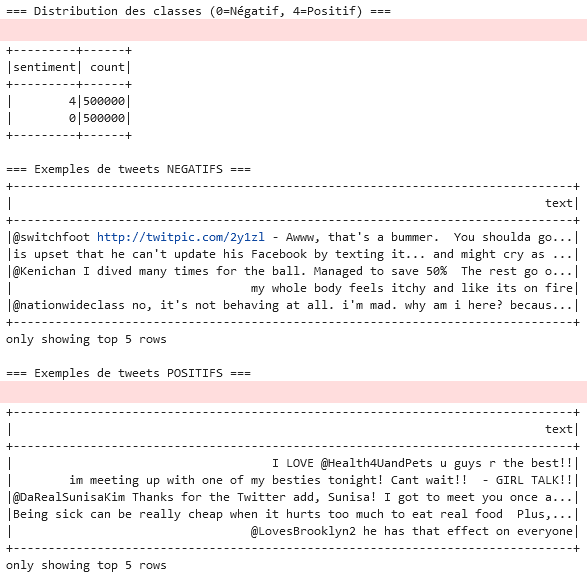

## 2. Conversion des labels

In [4]:
from pyspark.sql.functions import when

# ============================================================
# TODO [Exercice 2.1] : Conversion des labels
#
# Consigne : Ajoutez une colonne 'label' au DataFrame :
#            sentiment=4 → label=1.0 (positif)
#            sentiment=0 → label=0.0 (negatif)
#
# Indice   : when(col("sentiment") == 4, 1.0).otherwise(0.0)
#
# Attendu  : DataFrame 'df' avec une nouvelle colonne 'label' (DoubleType)
# ============================================================

df = df.withColumn("label", when(col("sentiment") == 4, 1.0).otherwise(0.0))

# Vérification rapide
df.select("sentiment", "label").show(5)

+---------+-----+
|sentiment|label|
+---------+-----+
|        0|  0.0|
|        0|  0.0|
|        0|  0.0|
|        0|  0.0|
|        0|  0.0|
+---------+-----+
only showing top 5 rows



## 3. Nettoyage du texte

**Important** : La fonction de nettoyage doit etre identique entre l'entrainement et l'inference (Phase 2).
Un ecart entre les deux (training-serving skew) degraderait les performances du modele.

In [5]:
import re
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType

# ============================================================
# TODO [Exercice 3.1] : Nettoyage du texte avec UDF
#
# Consigne : Definissez une fonction clean_text(text) qui :
#            1. Met en minuscules
#            2. Supprime les URLs (http...)
#            3. Supprime les mentions (@user)
#            4. Supprime le symbole #
#            5. Ne garde que les lettres et espaces
#            6. Normalise les espaces multiples
#            Puis creez une UDF et appliquez-la pour creer la colonne 'clean_text'
#
# Indice   : Regex utiles :
#            re.sub(r'http\S+', '', text)    # URLs
#            re.sub(r'@\w+', '', text)       # Mentions
#            re.sub(r'#', '', text)          # Symbole #
#            re.sub(r'[^a-zA-Z\s]', '', text) # Non-lettres
#            re.sub(r'\s+', ' ', text).strip() # Espaces
#
# Attendu  : DataFrame 'df' avec une colonne 'clean_text' nettoyee
#            IMPORTANT : cette meme fonction sera reutilisee en Phase 2 !
# ============================================================

def clean_text(text):
    """
    fonction de nettoyage à appliquer à chaque tweet pour les traiter de la même manière.
    doit être pareil en phase 1 qu'en phase 2
    """
    if text is None:
        return ""
    # passage en minuscules
    text = text.lower()
    
    #suppression des URLs
    text = re.sub(r"http\S+", "", text)

    #suppression des mentions @
    text = re.sub(r"@\w+", "", text)

    #suppression du symbole #
    text = re.sub(r"#", "", text)

    # suppression des caractères non alphabetiques, emoticones, etc (sauf les espaces qu'on garde)
    text = re.sub(r"[^a-z\s]", "", text)

    #normalisation des espaces (pour ne pas garder les multiples espaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

# on enregistre la fonction comme udf spark
clean_udf = udf(clean_text, StringType())

# on applique l'udf pour créer une colonne clean_text
df_clean = df.withColumn("clean_text", clean_udf(col("text")))

# affichage du avant et après pour vérifier
df_clean.select("text", "clean_text").show(5, truncate=60)

[Stage 12:>                                                         (0 + 1) / 1]

+------------------------------------------------------------+------------------------------------------------------------+
|                                                        text|                                                  clean_text|
+------------------------------------------------------------+------------------------------------------------------------+
|@switchfoot http://twitpic.com/2y1zl - Awww, that's a bum...|awww thats a bummer you shoulda got david carr of third d...|
|is upset that he can't update his Facebook by texting it....|is upset that he cant update his facebook by texting it a...|
|@Kenichan I dived many times for the ball. Managed to sav...|i dived many times for the ball managed to save the rest ...|
|              my whole body feels itchy and like its on fire|              my whole body feels itchy and like its on fire|
|@nationwideclass no, it's not behaving at all. i'm mad. w...|no its not behaving at all im mad why am i here because i...|
+-------

-> Pour préparer les donnés au machine learning, j'ai créé un UDF (User Defined Function) pour normaliser le texte. Le but est de réduier la taille du vocabulaire pour éliminer le "bruit" qui pourrait fausser l'apprentissage.

Tout d'abord, on passe le texte en minuscules, ensuite on supprime les URLs et les mentions avce les @. Pour les hashtages on garde le mot mais pas le symbole # et enfin on supprime tout ce qui n'est pas une lettre ou un espace, comme ça on supprime les émoticones.
Et on termine pas supprimer les espaces multiples.

## 4. Pipeline ML : TF-IDF + Logistic Regression

Le pipeline enchaine les etapes suivantes :
1. **RegexTokenizer** : decoupe le texte en mots
2. **StopWordsRemover** : supprime les mots vides (the, a, is...)
3. **CountVectorizer** : cree un vecteur de frequences de mots (Bag of Words)
4. **IDF** : pondere les frequences par l'Inverse Document Frequency
5. **LogisticRegression** : classifie le sentiment

In [6]:
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# ============================================================
# TODO [Exercice 4.1] : Construction du pipeline ML
#
# Consigne : Construisez un Pipeline avec 5 etapes :
#            1. RegexTokenizer (clean_text -> tokens)
#            2. StopWordsRemover (tokens -> filtered)
#            3. CountVectorizer (filtered -> raw_features, vocabSize=10000)
#            4. IDF (raw_features -> features)
#            5. LogisticRegression (features -> prediction, maxIter=10)
#
# Indice   : Pipeline(stages=[tokenizer, stopwords_remover, count_vectorizer, idf, lr])
#            Le resultat doit s'appeler 'pipeline'
#
# Attendu  : Un objet Pipeline avec 5 etapes
# ============================================================

# regex tokenizer  pour découper dès qu'on tombe sur un caractère qui n'est ni un mot ni un chiffre
tokenizer = RegexTokenizer(inputCol="clean_text",outputCol="tokens", pattern="\\W")

# supprime les mots vides 
remover = StopWordsRemover(inputCol="tokens",outputCol="filtered")

# contruction du dictionaire de fréquence
cv = CountVectorizer(inputCol="filtered",outputCol="raw_features",vocabSize=10000)

# diminue le poids des mots qui apparaissent partout, comme vu en cours
idf = IDF(inputCol="raw_features", outputCol="features")

# regression logistique pour classifier
lr = LogisticRegression(featuresCol="features",labelCol="label", maxIter=10)

# assemblage du pipeline
pipeline = Pipeline(stages=[tokenizer, remover, cv, idf, lr])

## 5. Entrainement

In [7]:
# ============================================================
# TODO [Exercice 5.1] : Split et entrainement
#
# Consigne : Divisez le dataset en train (80%) et test (20%) avec seed=42,
#            puis entrainez le pipeline sur le jeu de train.
#
# Indice   : df.randomSplit([0.8, 0.2], seed=42)
#            model = pipeline.fit(train)
#
# Attendu  : Variables 'train', 'test' et 'model' (PipelineModel)
# ============================================================
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

train, test = df_clean.randomSplit([0.8, 0.2], seed=42)

print("Entrainement du modèle")
model = pipeline.fit(train)

print("Modèle entrainé !")

Entrainement du modèle


26/02/08 22:08:57 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
                                                                                

Modèle entrainé !


## 6. Prediction et evaluation

In [8]:
# ============================================================
# TODO [Exercice 6.1] : Predictions
#
# Consigne : Appliquez le modele sur le jeu de test
#            et affichez un apercu des predictions.
#
# Indice   : predictions = model.transform(test)
#            predictions.select("text", "label", "prediction", "probability").show(10)
#
# Attendu  : Un DataFrame 'predictions' avec les colonnes prediction et probability
# ============================================================


predictions = model.transform(test)
predictions.select("text", "label", "prediction", "probability").show(10, truncate=60)

[Stage 30:>                                                         (0 + 1) / 1]

+------------------------------------------------------------+-----+----------+-----------------------------------------+
|                                                        text|label|prediction|                              probability|
+------------------------------------------------------------+-----+----------+-----------------------------------------+
|@Kenichan I dived many times for the ball. Managed to sav...|  0.0|       1.0|  [0.4768427471476246,0.5231572528523754]|
|                                                  Need a hug|  0.0|       0.0|  [0.6564475253316273,0.3435524746683727]|
|                         @Tatiana_K nope they didn't have it|  0.0|       0.0| [0.7653217610268968,0.23467823897310325]|
|@octolinz16 It it counts, idk why I did either. you never...|  0.0|       0.0| [0.8799963789472994,0.12000362105270057]|
|@FakerPattyPattz Oh dear. Were you drinking out of the fo...|  0.0|       0.0|  [0.5789109774656789,0.4210890225343211]|
|                       

In [9]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# ============================================================
# TODO [Exercice 6.2] : Evaluation du modele
#
# Consigne : Calculez les metriques suivantes :
#            - AUC-ROC (BinaryClassificationEvaluator)
#            - Accuracy (MulticlassClassificationEvaluator)
#            - F1-Score
#            - Precision et Recall ponderees
#
# Indice   : BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction")
#            MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
#            multi_eval.evaluate(predictions, {multi_eval.metricName: "accuracy"})
#
# Attendu  : AUC > 0.70, accuracy affichee
# ============================================================

auc = BinaryClassificationEvaluator(labelCol="label").evaluate(predictions)
print(f"AUC (Area Under ROC) : {auc:.4f}")

evaluator = MulticlassClassificationEvaluator(labelCol="label")

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
weighted_precision = evaluator.evaluate(predictions, {evaluator.metricName: "weightedPrecision"})
weighted_recall = evaluator.evaluate(predictions, {evaluator.metricName: "weightedRecall"})

print(f"Accuracy           : {accuracy:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"Précision pondérée : {weighted_precision:.4f}")
print(f"Recall pondéré    : {weighted_recall:.4f}")

AUC (Area Under ROC) : 0.8516


[Stage 48:==============>                                           (1 + 3) / 4]

Accuracy           : 0.7762
F1 Score           : 0.7760
Précision pondérée : 0.7771
Recall pondéré    : 0.7762


Après l'entrainement du modèle, je trouve une AUC (Area Under Roc) de 0.85, ce qui est au dessus des attentes (0.70) donc c'est un très bon résultat. Le modèle distingue bien les sentiments.

Au niveau de l'accuracy, j'obtiens 77.6%, ce qui signifie que presque 4 tweets sur 5 sont bien classés, donc c'est assez solide.

Donc le modèle détecte bien les tweet positifs avec 80.5% de rappel positif: VP/(VP+FN)

Mais il rate un peu plus les négatifs, avec 75% peut-être à cause de l'ironie employée, et de la négation : VN / (VN + FP)

In [10]:
# ============================================================
# TODO [Exercice 6.3] : Matrice de confusion
#
# Consigne : Affichez la matrice de confusion.
#
# Indice   : predictions.crosstab("label", "prediction").show()
#
# Attendu  : Tableau croise label vs prediction
# ============================================================

# matrice de confusion 
print("\nMatrice de Confusion")
predictions.crosstab("label", "prediction").show()


Matrice de Confusion


[Stage 58:=============================>                            (2 + 2) / 4]

+----------------+-----+-----+
|label_prediction|  0.0|  1.0|
+----------------+-----+-----+
|             1.0|19547|80525|
|             0.0|74899|25266|
+----------------+-----+-----+



## 7. Sauvegarde du modele

Le modele est sauvegarde sur HDFS a un chemin precis qui sera reutilise en Phase 2 pour l'inference en streaming.

In [11]:
# Sauvegarde sur HDFS
model.write().overwrite().save("hdfs:///models/LDF_sentiment_model")
print("Modele sauvegarde : ", "hdfs:///models/LDF_sentiment_model")

Modele sauvegarde :  hdfs:///models/LDF_sentiment_model


## 8. Verification du rechargement

In [12]:
from pyspark.ml import PipelineModel

# ============================================================
# TODO [Exercice 8.1] : Verification du rechargement du modele
#
# Consigne : Rechargez le modele depuis HDFS, puis testez-le
#            sur 5 tweets ecrits manuellement (positifs et negatifs).
#            N'oubliez pas d'appliquer le meme nettoyage (clean_text_udf) !
#
# Indice   : loaded_model = PipelineModel.load("hdfs:///models/sentiment_model")
#            Creez un DataFrame de test avec spark.createDataFrame(...)
#            Appliquez clean_text_udf puis loaded_model.transform(...)
#
# Attendu  : Le modele recharge predit correctement les 5 tweets
# ============================================================

# Rechargement du modèle depuis hdfs
loaded_model = PipelineModel.load("hdfs:///models/LDF_sentiment_model")

# Création de 5 tweets manuels (Raw Data)
tweets_5 = [
    ("I love Big Data and Spark, it is amazing!",),    # Doit être 1 (Positif)
    ("I hate waiting for the bus, it is terrible.",),   # Doit être 0 (Négatif)
    ("Best day of my life, so happy!",),               # Doit être 1 (Positif)
    ("This movie was really bad and boring.",),        # Doit être 0 (Négatif)
    ("I am not sure about this result.",)              # Incertain (Probablement 0)
]
df_tweets_5 = spark.createDataFrame(tweets_5, ["text"])

# je réapplique le même nettoyage que lors de l'entraînement, car le modele n'enregistre pas la fonction clean_udf de python
# je réutilise 'clean_udf' défini à plus tôt
df_tweets_5_clean = df_tweets_5.withColumn("clean_text", clean_udf(col("text")))

# test des prédictions avec le modèle chargé
predictions_manual = loaded_model.transform(df_tweets_5_clean)

# Affichage des résultats
print("Résultats du Test Manuel")
predictions_manual.select("text", "prediction", "probability").show(truncate=False)


Résultats du Test Manuel


+-------------------------------------------+----------+----------------------------------------+
|text                                       |prediction|probability                             |
+-------------------------------------------+----------+----------------------------------------+
|I love Big Data and Spark, it is amazing!  |1.0       |[0.12888880575266065,0.8711111942473393]|
|I hate waiting for the bus, it is terrible.|0.0       |[0.968729128047994,0.03127087195200595] |
|Best day of my life, so happy!             |1.0       |[0.083491342363706,0.916508657636294]   |
|This movie was really bad and boring.      |0.0       |[0.8992245838238672,0.10077541617613284]|
|I am not sure about this result.           |1.0       |[0.29317333428346043,0.7068266657165396]|
+-------------------------------------------+----------+----------------------------------------+



J'ai réalisé des prédictions pour un petit dataframe de 5 tweets (j'ai généré le dataframe avec l'ia pour que ce soit divers et en anglais) et on obtient des prédictions intéressantes :

Les tweets 1 et 3 sont clairement positifs ("love", "amazing", "best", "happy") et sont bien prédis en positifs, de manière assez certaine (87% de proba pour le premier et 91% pour le 3ème, proba d'être positif) !

Les tweets 2 et 4 sont au contraire clairement négatifs ("hate", "terrible", "bad", "boring") et sont bien prédis comme tel avec respectivement 96% et 89% de certitude.

Le 5ème tweet en revanche, est moins certain, en effet il est volontairement confusant ("I am not sure about this result.") et le modèle l'a alors prédit comme positif, mais avec une certitude plus faible, de 70% (qu'il soit positif) et 29% qu'il soit négatif.

## Modèle n°2 : On va essayer d'implémenter un nouveau modèle pour voir si on pourrait avoir de meilleurs résultats : N_grams

### Pipeline n-gram en bigram

In [13]:
from pyspark.ml.feature import NGram, RegexTokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

print("Entraînement du modèle N-Gram")

# Construction du Pipeline

# tokenizer pour le ngram
tokenizer_ng = RegexTokenizer(inputCol="clean_text", outputCol="tokens", pattern="\\W")

# stopWords
remover_ng = StopWordsRemover(inputCol="tokens", outputCol="filtered")

# bigram : on lie les mots par 2  
ngram_ng = NGram(n=2, inputCol="filtered", outputCol="bigrams")

# CountVectorizer
# On augmente vocabSize à 20000 car il y a plus de combinaisons de 2 mots que de mots seuls
cv_ng = CountVectorizer(inputCol="bigrams", outputCol="raw_features", vocabSize=20000)

# IDF & Logistic Regression
idf_ng = IDF(inputCol="raw_features", outputCol="features")
lr_ng = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)

pipeline_ng = Pipeline(stages=[tokenizer_ng, remover_ng, ngram_ng, cv_ng, idf_ng, lr_ng])

Entraînement du modèle N-Gram


In [15]:
# entrainement du modèle
from pyspark.sql.functions import col

if "clean_text" not in df.columns:
    print("Génération de la colonne 'clean_text'...")
    df = df.withColumn("clean_text", clean_udf(col("text")))
    
train_ng, test_ng = df.randomSplit([0.8, 0.2], seed=42)

print("Entraînement du modèle Bigram")
model_ng = pipeline_ng.fit(train_ng)

Génération de la colonne 'clean_text'...
Entraînement du modèle Bigram


In [16]:
# Évaluation du modèle ngram
predictions_ng = model_ng.transform(test_ng)

# auc
auc_ng = BinaryClassificationEvaluator(labelCol="label").evaluate(predictions_ng)

# Accuracy
evaluator_ng = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
acc_ng = evaluator_ng.evaluate(predictions_ng)

print("\nRÉSULTATS DU MODÈLE BONUS (BIGRAMS)")
print(f"Nouvelle AUC      : {auc_ng:.4f}")
print(f"Nouvelle Accuracy : {acc_ng:.4f}")

# Petit comparatif automatique
ancien_auc = 0.8516 
gain = auc_ng - ancien_auc
print(f"Gain de performance : {gain:+.4f}")

[Stage 127:============================>                            (2 + 2) / 4]


RÉSULTATS DU MODÈLE BONUS (BIGRAMS)
Nouvelle AUC      : 0.7540
Nouvelle Accuracy : 0.6756
Gain de performance : -0.0976


In [17]:
# Sauvegarde
model_path_ng = "hdfs:///models/LDF_sentiment_model_ngram"
model_ng.write().overwrite().save(model_path_ng)
print(f"\nModèle Bonus sauvegardé dans : {model_path_ng}")


Modèle Bonus sauvegardé dans : hdfs:///models/LDF_sentiment_model_ngram


### Analyse des résultats de mon nouveau modèle

Pour essayer d'innover, j'ai tenté d'implémenter une approche par bigrams (donc des n_grams de 2).

Le modèle précédent (Bag of Words) traitait les mots individuellement et échouait sur les négations, donc si il y avait un tweet négatif comme "... not good", le modèle supprimait "no" qui est assez récurrent, et gardait donc "good" et cela classait le tweet comme positif, ce qui était erroné.

Mon auc précédente était de 0.8516 et maintenant j'ai 0.7542 donc c'est suffisant par rapport à la demande de 0.7 minimum, mais c'est quand même moins bien que l'auc précédente. 

L'utilisation des N-Grams permet de capter une partie de la sémantique et du contexte de la phrase. C'est une méthode plutôt efficace pour améliorer la détection des sentiments complexes sans rallonger le temps de calcul. 

Mais en finalité, le modèle est un peu moins bon que le modèle précédent donc je ne vais conserver que le premier ("LDF_sentiment_model")

On va quand même le tester sur le même dataframe de test de 5 tweets :

In [18]:
# Rechargement du modèle depuis hdfs
loaded_model = PipelineModel.load("hdfs:///models/LDF_sentiment_model_ngram")

# Création de 5 tweets manuels (Raw Data)
tweets_5 = [
    ("I love Big Data and Spark, it is amazing!",),    # Doit être 1 (Positif)
    ("I hate waiting for the bus, it is terrible.",),   # Doit être 0 (Négatif)
    ("Best day of my life, so happy!",),               # Doit être 1 (Positif)
    ("This movie was really bad and boring.",),        # Doit être 0 (Négatif)
    ("I am not sure about this result.",)              # Incertain (Probablement 0)
]
df_tweets_5 = spark.createDataFrame(tweets_5, ["text"])

# je réapplique le même nettoyage que lors de l'entraînement, car le modele n'enregistre pas la fonction clean_udf de python
# je réutilise 'clean_udf' défini à plus tôt
df_tweets_5_clean = df_tweets_5.withColumn("clean_text", clean_udf(col("text")))

# test des prédictions avec le modèle chargé
predictions_manual = loaded_model.transform(df_tweets_5_clean)

# Affichage des résultats
print("Résultats du Test Manuel")
predictions_manual.select("text", "prediction", "probability").show(truncate=False)

Résultats du Test Manuel
+-------------------------------------------+----------+-----------------------------------------+
|text                                       |prediction|probability                              |
+-------------------------------------------+----------+-----------------------------------------+
|I love Big Data and Spark, it is amazing!  |1.0       |[0.3553291473359891,0.6446708526640109]  |
|I hate waiting for the bus, it is terrible.|0.0       |[0.9511168526085967,0.048883147391403314]|
|Best day of my life, so happy!             |1.0       |[0.15377883529698427,0.8462211647030158] |
|This movie was really bad and boring.      |0.0       |[0.644575444296165,0.355424555703835]    |
|I am not sure about this result.           |1.0       |[0.4651321698107144,0.5348678301892855]  |
+-------------------------------------------+----------+-----------------------------------------+



## Modèle n°3 : On va essayer d'implémenter un nouveau modèle pour voir si on pourrait avoir de meilleurs résultats : algo Naïve Bayes

In [19]:
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

print("Entraînement Naïve Bayes, avec les unigrams")

# 1. Pipeline identique au premier modèle
tokenizer_nb = RegexTokenizer(inputCol="clean_text", outputCol="tokens", pattern="\\W")
remover_nb = StopWordsRemover(inputCol="tokens", outputCol="filtered")

# On reste sur des Unigrams
# On garde la même taille de vocabulaire (10k)
cv_nb = CountVectorizer(inputCol="filtered", outputCol="raw_features", vocabSize=10000)
idf_nb = IDF(inputCol="raw_features", outputCol="features")

# 2. on change l'Algorithme
# modelType="multinomial" est adapté aux comptes de mots (TF-IDF ou Count)
nb = NaiveBayes(smoothing=1.0, modelType="multinomial", featuresCol="features", labelCol="label")

# pipeline
pipeline_nb = Pipeline(stages=[tokenizer_nb, remover_nb, cv_nb, idf_nb, nb])

Entraînement Naïve Bayes, avec les unigrams


In [20]:
# entraînement
train_nb, test_nb = df.randomSplit([0.8, 0.2], seed=42)
model_nb = pipeline_nb.fit(train_nb)

In [21]:
# évaluation du modèle
predictions_nb = model_nb.transform(test_nb)

auc_nb = BinaryClassificationEvaluator(labelCol="label").evaluate(predictions_nb)
acc_nb = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy").evaluate(predictions_nb)

print("\nRÉSULTATS NAÏVE BAYES (Unigrams)")
print(f"AUC      : {auc_nb:.4f}")
print(f"Accuracy : {acc_nb:.4f}")

[Stage 186:==============>                                          (1 + 3) / 4]


RÉSULTATS NAÏVE BAYES (Unigrams)
AUC      : 0.5380
Accuracy : 0.7601


In [22]:
# Comparaison directe avec le modèle LogReg sauvegardé
score_ref = 0.8516 
diff = auc_nb - score_ref
print(f"Différence vs LogReg : {diff:+.4f}")

Différence vs LogReg : -0.3136


-> A nouveau, ce modèle (avec une modif d'algo) est moins bon que le premier. Il est à peine mieux que le hasard.

## Modèle n°4 : Test d'un nouveau modèle

Pour ce modèle, j'ai changé d'approche car le premier modèle que j'ai (le plus performant) est celui fourni don ce n'est pas très innovant. 

Pour celui-ci, l'approche est différente au niveau du traitement des données. Grâce aux unigrams, aux bigrams et aux trigrams, on récupère différentes manières de voir les expressions, et on assemble tout dans un vecteur (grâce au vectorAssembler), ensuite on pondère, grâce à un IDF, puis on narmalize pour tout mettre entre 0 et 1.

au niveau du classifier je garde la régression logistique pour le moment.

In [23]:
import re
from pyspark.sql.functions import udf, col
from pyspark.sql.types import StringType

# 1. On s'assure que la fonction de nettoyage est bien définie
def clean_text(text):
    if text is None: return ""
    text = text.lower()
    text = re.sub(r"http\S+", "", text)       # URLs
    text = re.sub(r"@\w+", "", text)         # Mentions
    text = re.sub(r"#", "", text)            # Hashtags
    text = re.sub(r"[^a-z\s]", "", text)     # Caractères spéciaux
    text = re.sub(r"\s+", " ", text).strip() # Espaces multiples
    return text

clean_udf = udf(clean_text, StringType())

# 2. CRUCIAL : On applique le nettoyage AVANT de diviser en train/test
# Si 'clean_text' n'existe pas, on la crée.
if "clean_text" not in df.columns:
    print("Génération de la colonne 'clean_text'...")
    df = df.withColumn("clean_text", clean_udf(col("text")))
else:
    print("La colonne 'clean_text' existe déjà.")

# 3. Maintenant on peut faire le split sur des données PROPRES
train_final, test_final = df.randomSplit([0.8, 0.2], seed=42)

# 4. Définition du Pipeline (Rappel du code Champion)
from pyspark.ml.feature import NGram, RegexTokenizer, StopWordsRemover, CountVectorizer, IDF, VectorAssembler, Normalizer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

# Pipeline Stacking + Normalizer
# 1. On prend tout (Mots, Paires, Trios)
# 2. On Normalise les vecteurs (L2 Norm)
# 3. On laisse la Régression Logistique faire le tri

print("Démarrage du Pipeline")

# 1. Nettoyage de base
tokenizer_final = RegexTokenizer(inputCol="clean_text", outputCol="tokens", pattern="\\W")
remover_final = StopWordsRemover(inputCol="tokens", outputCol="filtered")


# BRANCHE 1 : Unigrams (Les mots simples)
cv_uni = CountVectorizer(inputCol="filtered", outputCol="vec_uni", vocabSize=10000)


# BRANCHE 2 : Bigrams (Le contexte local)
ngram_bi = NGram(n=2, inputCol="filtered", outputCol="bigrams")
cv_bi = CountVectorizer(inputCol="bigrams", outputCol="vec_bi", vocabSize=10000)


# BRANCHE 3 : Trigrams (Les expressions)
ngram_tri = NGram(n=3, inputCol="filtered", outputCol="trigrams")
cv_tri = CountVectorizer(inputCol="trigrams", outputCol="vec_tri", vocabSize=5000)


# On colle les 3 vecteurs ensemble
assembler = VectorAssembler(
    inputCols=["vec_uni", "vec_bi", "vec_tri"], 
    outputCol="raw_vectors"
)

# IDF (Pondération)
idf_final = IDF(inputCol="raw_vectors", outputCol="idf_features")

# normalizer
# Met tout sur une échelle de 0 à 1 (L2 Norm)
normalizer = Normalizer(inputCol="idf_features", outputCol="features", p=2.0)

# On reste sur LogisticRegression car elle gère mieux les données normalisées que Naïve Bayes
lr_final = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)

# PIPELINE
pipeline_final = Pipeline(stages=[
    tokenizer_final, remover_final,      # Preprocessing
    ngram_bi, ngram_tri,                 # Génération N-Grams
    cv_uni, cv_bi, cv_tri,               # Vectorisation
    assembler,                           # Fusion
    idf_final,                           # TF-IDF
    normalizer,                          # Normalisation
    lr_final                             # Modèle
])

# 2. Entraînement
train_final, test_final = df.randomSplit([0.8, 0.2], seed=42)

print("Entraînement du modèle")
model_final = pipeline_final.fit(train_final)

# 3. Évaluation
predictions_final = model_final.transform(test_final)

auc_final = BinaryClassificationEvaluator(labelCol="label").evaluate(predictions_final)
acc_final = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy").evaluate(predictions_final)

print("\nRÉSULTATS")
print(f"AUC      : {auc_final:.4f}")
print(f"Accuracy : {acc_final:.4f}")

# Comparaison
score_ref = 0.8516 
diff = auc_final - score_ref
print(f"Gain total : {diff:+.4f}")


model_final.write().overwrite().save("hdfs:///models/LDF_sentiment_model_stack_norm")

La colonne 'clean_text' existe déjà.
Démarrage du Pipeline
Entraînement du modèle


26/02/08 22:37:05 WARN DAGScheduler: Broadcasting large task binary with size 1763.7 KiB
26/02/08 22:37:17 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:28 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:39 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:40 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:40 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:40 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/02/08 22:37:40 WARN DAGScheduler: Broadcasting l


RÉSULTATS
AUC      : 0.8667
Accuracy : 0.7846
Gain total : +0.0151


In [24]:
from pyspark.ml import PipelineModel

# Rechargement du modèle depuis hdfs
loaded_model = PipelineModel.load("hdfs:///models/LDF_sentiment_model_stack_norm")

# Création de 5 tweets manuels (Raw Data)
tweets_5 = [
    ("I love Big Data and Spark, it is amazing!",),    # Doit être 1 (Positif)
    ("I hate waiting for the bus, it is terrible.",),   # Doit être 0 (Négatif)
    ("Best day of my life, so happy!",),               # Doit être 1 (Positif)
    ("This movie was really bad and boring.",),        # Doit être 0 (Négatif)
    ("I am not sure about this result.",)              # Incertain (Probablement 0)
]
df_tweets_5 = spark.createDataFrame(tweets_5, ["text"])

# je réapplique le même nettoyage que lors de l'entraînement, car le modele n'enregistre pas la fonction clean_udf de python
# je réutilise 'clean_udf' défini à plus tôt
df_tweets_5_clean = df_tweets_5.withColumn("clean_text", clean_udf(col("text")))

# test des prédictions avec le modèle chargé
predictions_manual = loaded_model.transform(df_tweets_5_clean)

# Affichage des résultats
print("Résultats du Test Manuel")
predictions_manual.select("text", "prediction", "probability").show(truncate=False)

Résultats du Test Manuel
+-------------------------------------------+----------+-----------------------------------------+
|text                                       |prediction|probability                              |
+-------------------------------------------+----------+-----------------------------------------+
|I love Big Data and Spark, it is amazing!  |1.0       |[0.1618879218478466,0.8381120781521534]  |
|I hate waiting for the bus, it is terrible.|0.0       |[0.9919739660349006,0.008026033965099377]|
|Best day of my life, so happy!             |1.0       |[0.031079070601557603,0.9689209293984424]|
|This movie was really bad and boring.      |0.0       |[0.857516186993147,0.14248381300685298]  |
|I am not sure about this result.           |1.0       |[0.2579730682338476,0.7420269317661524]  |
+-------------------------------------------+----------+-----------------------------------------+



-> En résultat, on trouve alors une AUC de 86.67%, ce qui est déjà mieux que mon premier modèle, et une accuracy de 78.47 donc c'est super.

On garde donc ce modèle ci.

## 9. Arret de la SparkSession

In [25]:
spark.stop()
print("SparkSession arretee.")

SparkSession arretee.
